In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1

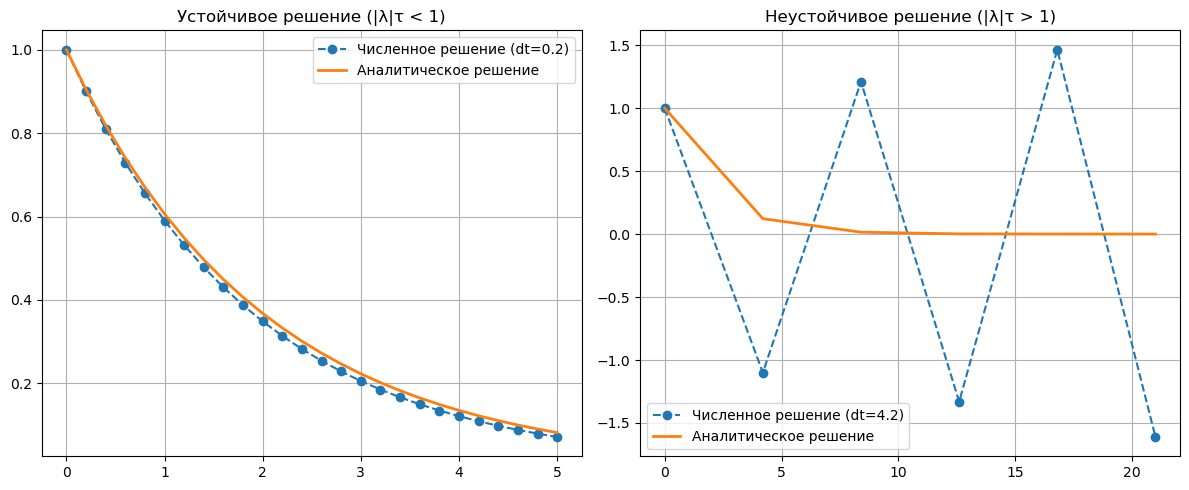

In [2]:
def euler_solve(lam, u0, T, dt):
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty(num_steps + 1)
    y[0] = u0
    for k in range(num_steps):
        y[k+1] = y[k] + dt * lam * y[k]
    return tt, y


lam = -0.5
tt1, y1 = euler_solve(lam, u0=1.0, T=5, dt=0.1/abs(lam))

tt2, y2 = euler_solve(lam, u0=1.0, T=12/abs(lam), dt=2.1/abs(lam))

plt.figure(figsize=(12, 5))

# График для dt = 0.2
plt.subplot(1, 2, 1)
plt.plot(tt1, y1, 'o--', label='Численное решение (dt=0.2)')
plt.plot(tt1, np.exp(lam * tt1), '-', lw=2, label='Аналитическое решение')
plt.legend(loc='best')
plt.grid(True)
plt.title('Устойчивое решение (|λ|τ < 1)')

# График для dt = 4.2
plt.subplot(1, 2, 2)
plt.plot(tt2, y2, 'o--', label='Численное решение (dt=4.2)')
plt.plot(tt2, np.exp(lam * tt2), '-', lw=2, label='Аналитическое решение')
plt.legend(loc='best')
plt.grid(True)
plt.title('Неустойчивое решение (|λ|τ > 1)')

plt.tight_layout()
plt.show()

# 2

In [25]:
def euler_solve2(a, u0, T, dt):
    """Solve the system du/dt = Au via an explicit Euler scheme.

    Parameters
    ----------
    a : ndarray, shape(ndim, ndim)
        The matrix of the l.h.s.
    u0 : ndarray, shape(ndim,)
        Initial condition
    T : float
        construct the solution for $t\in [0, T)$
    dt : float
        Integration step size $\tau$

    Returns
    -------
    t : ndarray, shape (n,)
        Integration times
    y : ndarray, shape (n, ndim)
        Solution of the FD system.
        y[k, :] is the solution at t[k].
    """
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    ndim = a.shape[0]
    y = np.empty([num_steps+1, ndim])
    y[0] = u0
    for k in range(num_steps):
        y[k+1] = y[k] + dt* a @ y[k]
    return tt, y
    raise NotImplementedError()

In [26]:
from scipy.linalg import expm

def mat_exp_solve(a, u0, tt):
    """Construct the solution of $du/dt = A u$ with $u(t=0) = u_0$ at times `tt`.

    Parameters
    ----------
    a : ndarray, shape (ndim, ndim)

    u0 : ndarray, shape (ndim,)

    tt : ndarray, shape (n,)
        The values of $t$

    Return
    ------
    u : ndarray, shape (n, ndim)
        u[:, k] is $\exp(t[k] A)$
    """
    ndim = a.shape[0]
    y = np.empty([len(tt), ndim])
    y[0] = u0
    for k in range(len(tt)-1):
        y[k+1] = expm(a*tt[k]) @ u0
    return y
    raise NotImplementedError()

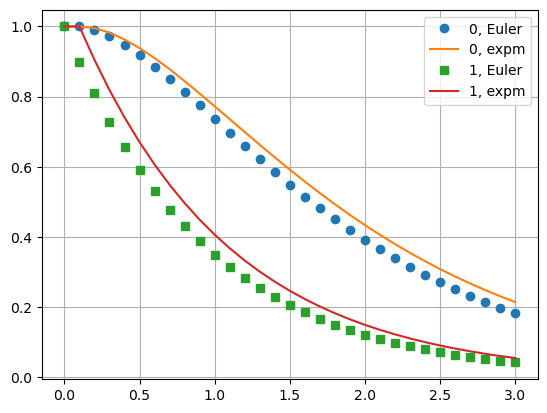

In [27]:
# Solve via Euler's method, compare to the matrix exponential

from scipy.linalg import expm

a = np.array([[-1, 1],
              [0, -1]], dtype=float)
t, y  = euler_solve2(a, u0=[1, 1], T=3, dt=0.1)
ym = mat_exp_solve(a, [1, 1], t)

plt.plot(t, y[:, 0], 'o', label='0, Euler')
plt.plot(t, ym[:, 0], '-', label='0, expm')

plt.plot(t, y[:, 1], 's', label='1, Euler')
plt.plot(t, ym[:, 1], '-', label='1, expm')

plt.legend(loc='best')
plt.grid(True)

# 3

In [28]:
A = np.array([[-10, 10],[32,-499]])
print('Собственные значения:', np.linalg.eigvals(A))
print('Система является жесткой, так как max/min =', int(np.linalg.eigvals(A)[1]/np.linalg.eigvals(A)[0]))

Собственные значения: [  -9.34647667 -499.65352333]
Система является жесткой, так как max/min = 53


In [29]:
dt = 0.01
y = np.empty([int(1/dt), 2])
y[0] = [1, 0]
for i in range(int(1/0.01)-1):
  f1 = A @ y[i]
  f2 = A @ (y[i]+dt*f1/2)
  y[i+1] = y[i] + dt*f2
print(y[99])

[ 1.16717810e+89 -5.71512871e+90]


## явная

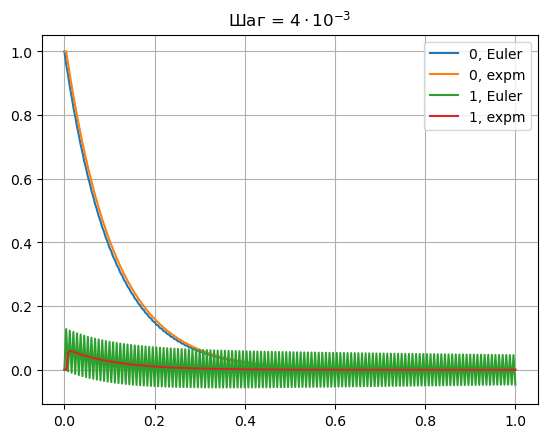

In [30]:
dt = 4*1e-3
u0 = [1, 0]
T = 1
t, y  = euler_solve2(A, u0, T, dt)
ym = mat_exp_solve(A, u0, t)

plt.plot(t, y[:, 0],  label='0, Euler')
plt.plot(t, ym[:, 0],  label='0, expm')

plt.plot(t, y[:, 1], label='1, Euler')
plt.plot(t, ym[:, 1],  label='1, expm')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Шаг = $4 \cdot 10^{-3}$')
plt.show()

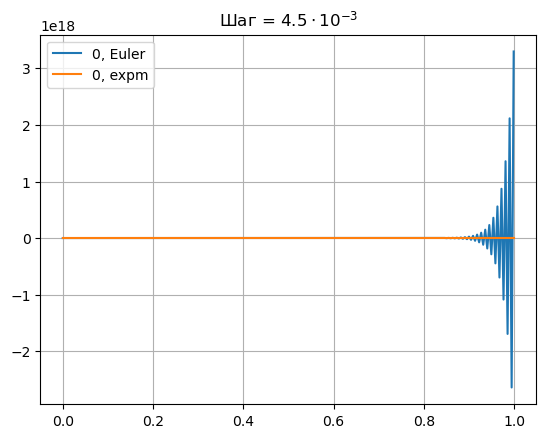

In [31]:
dt = 4.5*1e-3
u0 = [1, 0]
T = 1
t, y  = euler_solve2(A, u0, T, dt)
ym = mat_exp_solve(A, u0, t)

plt.plot(t, y[:, 0],  label='0, Euler')
plt.plot(t, ym[:, 0],  label='0, expm')

# plt.plot(t, y[:, 1], label='1, Euler')
# plt.plot(t, ym[:, 1],  label='1, expm')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Шаг = $4.5 \cdot 10^{-3}$')
plt.show()

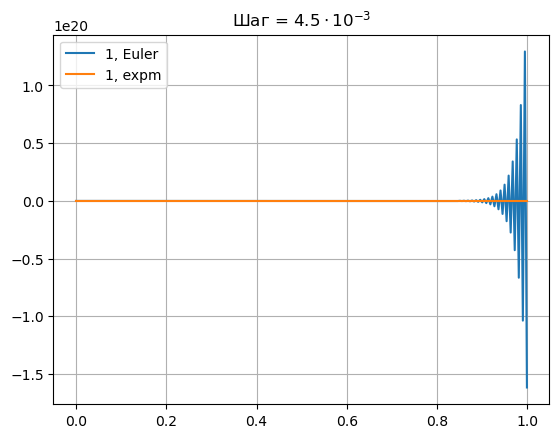

In [32]:
dt = 4.5*1e-3
u0 = [1, 0]
T = 1
t, y  = euler_solve2(A, u0, T, dt)
ym = mat_exp_solve(A, u0, t)

# plt.plot(t, y[:, 0],  label='0, Euler')
# plt.plot(t, ym[:, 0],  label='0, expm')

plt.plot(t, y[:, 1], label='1, Euler')
plt.plot(t, ym[:, 1],  label='1, expm')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Шаг = $4.5 \cdot 10^{-3}$')
plt.show()

## неявная

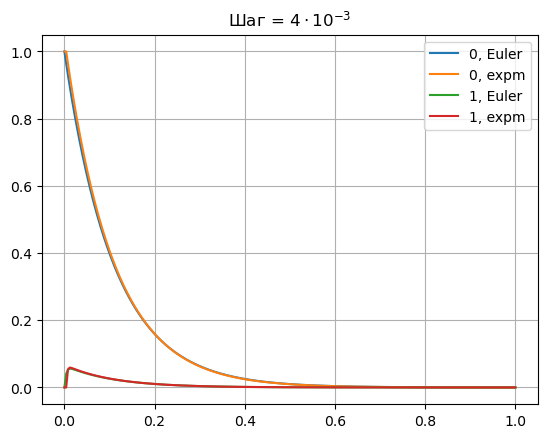

In [33]:
dt = 4*1e-3
y = np.empty([int(1/dt)+1, 2])
t, y1  = euler_solve2(A, u0, T, dt)
ym = mat_exp_solve(A, u0, t)
y[0] = [1, 0]
for i in range(int(1/dt)):
  y[i+1] = np.linalg.solve(A-np.eye(2)/dt,-y[i]/dt)

plt.plot(t, y[:, 0], label='0, Euler')
plt.plot(t, ym[:, 0],label='0, expm')

plt.plot(t, y[:, 1], label='1, Euler')
plt.plot(t, ym[:, 1], label='1, expm')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Шаг = $4 \cdot 10^{-3}$')
plt.show()

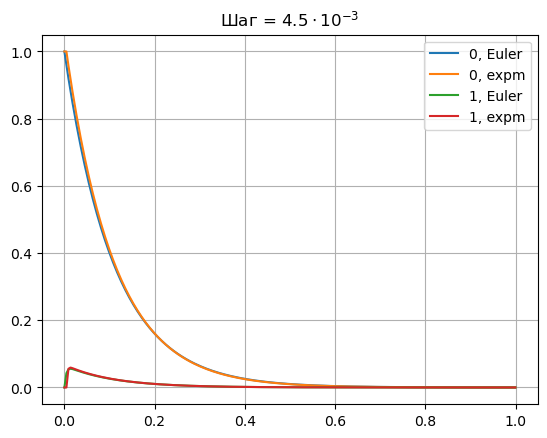

In [34]:
dt = 4.5*1e-3
y = np.empty([int(1/dt)+1, 2])
t, y1  = euler_solve2(A, u0, T, dt)
ym = mat_exp_solve(A, u0, t)
y[0] = [1, 0]
for i in range(int(1/dt)):
  y[i+1] = np.linalg.solve(A-np.eye(2)/dt,-y[i]/dt)

plt.plot(t, y[:, 0], label='0, Euler')
plt.plot(t, ym[:, 0], label='0, expm')

plt.plot(t, y[:, 1], label='1, Euler')
plt.plot(t, ym[:, 1], label='1, expm')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Шаг = $4.5 \cdot 10^{-3}$')
plt.show()

# 6

## явный Эйлер

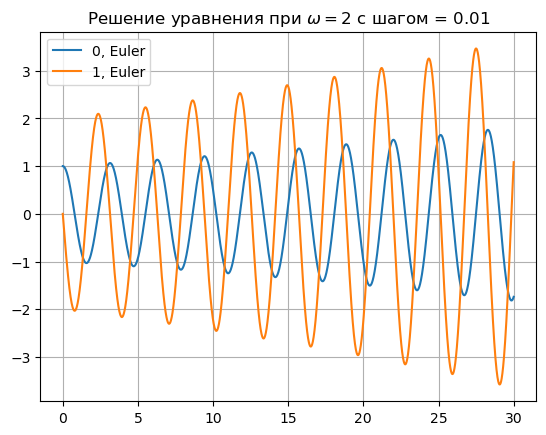

In [36]:
w = 2
A = np.array([[0,1],[-w**2, 0]])
dt = 0.01
u0 = [1, 0]
T = 30
t, y  = euler_solve2(A, u0, T, dt)

plt.plot(t, y[:, 0], label='0, Euler')

plt.plot(t, y[:, 1], label='1, Euler')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Решение уравнения при $\omega = 2$ с шагом = 0.01')
plt.show()

## проверка ЗС


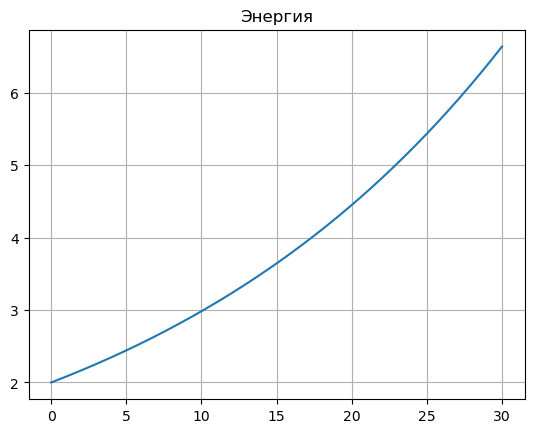

In [38]:
E = np.empty(t.shape)
E = (y[:, 1])**2/2 + (y[:, 0]*w)**2/2
plt.plot(t, E)

plt.grid(True)
plt.title(r'Энергия')
plt.show()

## схема Р-К

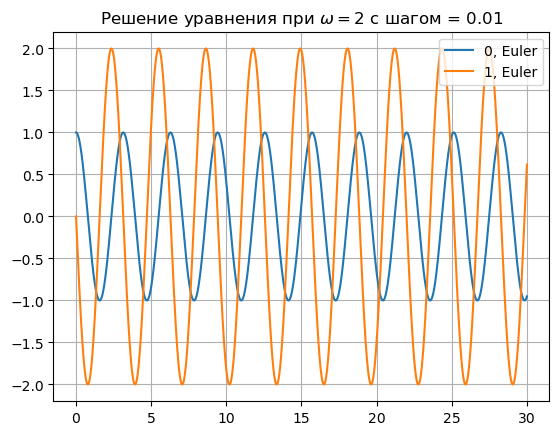

In [39]:
w = 2
A = np.array([[0,1],[-w**2, 0]])
dt = 0.01
u0 = [1, 0]
T = 30
t, y0  = euler_solve2(A, u0, T, dt)
y = np.empty([int(T/dt)+1, 2])
y[0] = [1, 0]
for i in range(int(T/dt)):
  f1 = A @ y[i]
  f2 = A @ (y[i]+dt*f1/2)
  y[i+1] = y[i] + dt*f2

plt.plot(t, y[:, 0], label='0, Euler')

plt.plot(t, y[:, 1], label='1, Euler')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Решение уравнения при $\omega = 2$ с шагом = 0.01')
plt.show()

## проверка ЗС


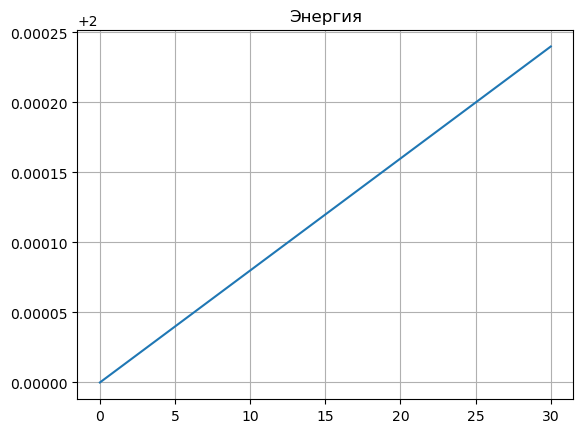

In [41]:
E = np.empty(t.shape)
E = (y[:, 1])**2/2 + (y[:, 0]*w)**2/2
plt.plot(t, E)

plt.grid(True)
plt.title(r'Энергия')
plt.show()

## сравнение с точным решением

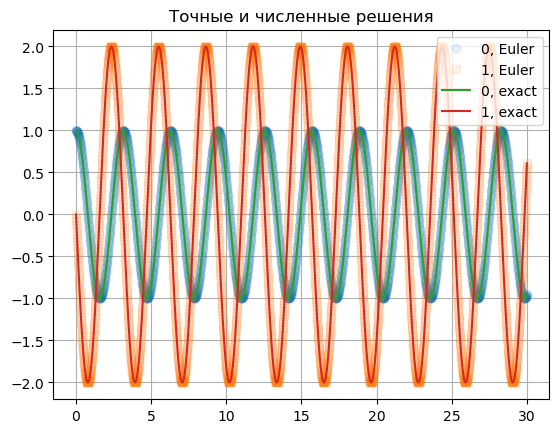

In [50]:
plt.plot(t, y[:, 0], 'o', alpha=0.1, label='0, Euler')
plt.plot(t, y[:, 1], 's', alpha=0.1, label='1, Euler')
plt.plot(t, np.cos(2*t), '-', label='0, exact')
plt.plot(t, -2*np.sin(2*t), '-', label='1, exact')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Точные и численные решения')
plt.show()

## корректор

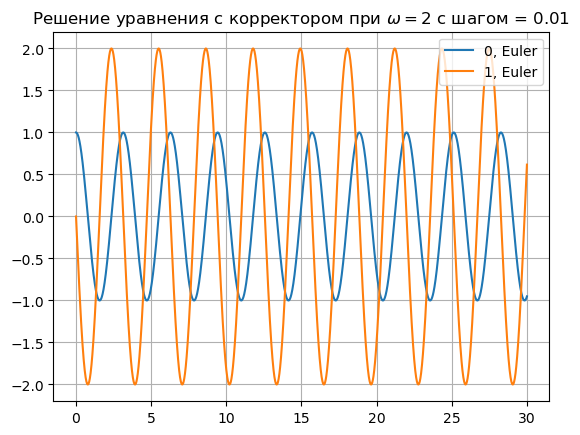

In [51]:
w = 2
A = np.array([[0,1],[-w**2, 0]])
dt = 0.01
u0 = [1, 0]
T = 30
t, y0  = euler_solve2(A, u0, T, dt)
y = np.empty([int(T/dt)+1, 2])
y[0] = [1, 0]
E0 = (w)**2/2
for i in range(int(T/dt)):
  f1 = A @ y[i]
  f2 = A @ (y[i]+dt*f1/2)
  y[i+1] = y[i] + dt*f2
  if y[i+1,0] > 0:
    y[i+1,0] = (2*E0 - (y[i+1, 1])**2)**(1/2)/w
  else:
    y[i+1,0] = -(2*E0 - (y[i+1, 1])**2)**(1/2)/w

plt.plot(t, y[:, 0], label='0, Euler')

plt.plot(t, y[:, 1], label='1, Euler')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Решение уравнения с корректором при $\omega = 2$ с шагом = 0.01')
plt.show()

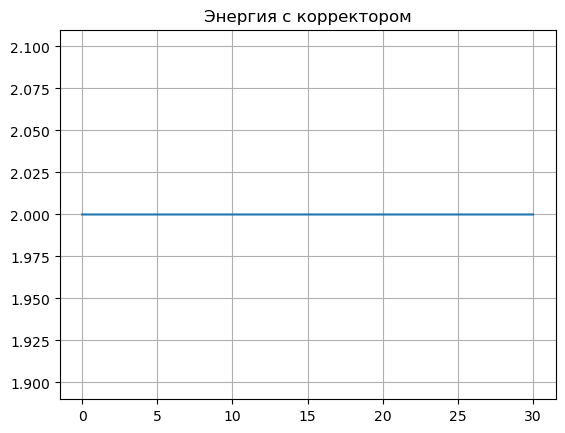

In [52]:
E = np.empty(t.shape)
E = (y[:, 1])**2/2 + (y[:, 0]*w)**2/2
plt.plot(t, E)

plt.grid(True)
plt.title(r'Энергия с корректором')
plt.show()

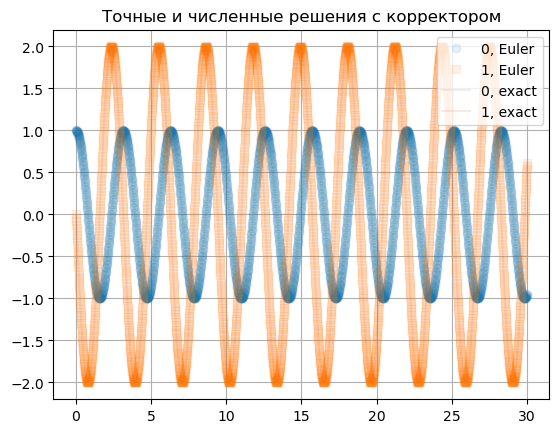

In [53]:
plt.plot(t, y[:, 0], 'o', alpha=0.1, label='0, Euler')
plt.plot(t, y[:, 1], 's', alpha=0.1, label='1, Euler')
plt.plot(t, np.cos(2*t), '-', alpha=0.1, label='0, exact')
plt.plot(t, -2*np.sin(2*t), '-', alpha=0.1, label='1, exact')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Точные и численные решения с корректором')
plt.show()

# 7

In [54]:
w = 2
A = np.array([[0,1],[-w**2, 0]])
y0 = [1, 0]
T = 30

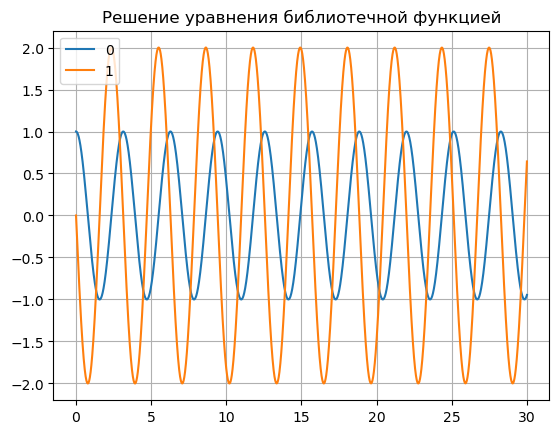

In [55]:
from scipy.integrate import solve_ivp
def func(t, y): return A @ y
sol = solve_ivp(func, [0, T], y0, t_eval=np.linspace(0,T,3000))

plt.plot(sol.t, sol.y[0], label='0')

plt.plot(sol.t, sol.y[1], label='1')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Решение уравнения библиотечной функцией')
plt.show()

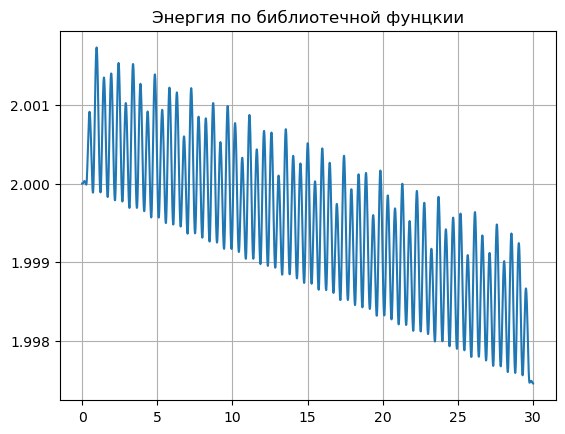

In [56]:
E = np.empty(sol.t.shape)
E = (sol.y[1])**2/2 + (sol.y[0]*w)**2/2
plt.plot(sol.t, E)

plt.grid(True)
plt.title(r'Энергия по библиотечной фунцкии')
plt.show()

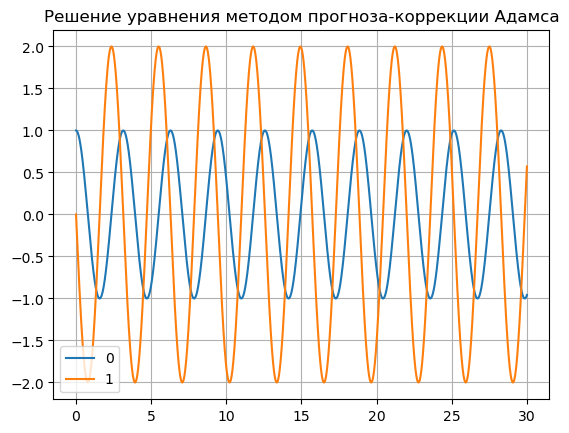

In [57]:
y = sol.y
h = T/3000
for i in range(3, len(y[0])-1):
  tmp = y[:, i]+(h/24)*(-9*A @ y[:, i-3]+37*A @ y[:, i-2]-59*A @ y[:, i-1]+55*A @ y[:, i])
  y[:, i+1] = y[:, i]+(h/24)*(A @ y[:, i-2]-5*A @ y[:, i-1]+19*A @ y[:, i]+9*A @ tmp)

plt.plot(sol.t, y[0], label='0')

plt.plot(sol.t, y[1], label='1')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Решение уравнения методом прогноза-коррекции Адамса')
plt.show()

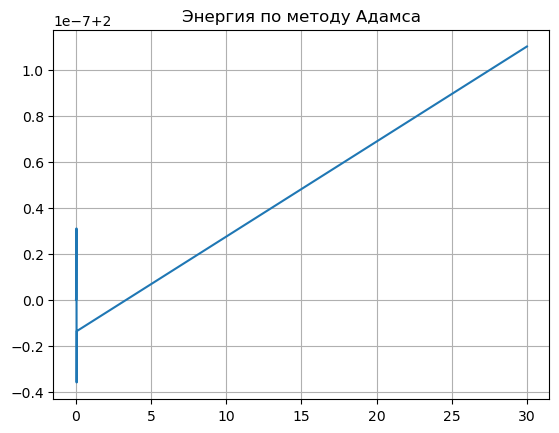

In [58]:
E = np.empty(sol.t.shape)
E = (y[1])**2/2 + (y[0]*w)**2/2
plt.plot(sol.t, E)

plt.grid(True)
plt.title(r'Энергия по методу Адамса')
plt.show()

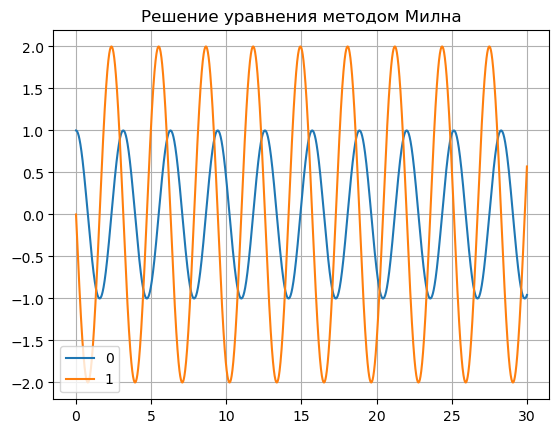

In [59]:
y = sol.y
h = T/3000
for i in range(3, len(y[0])-1):
  tmp1 = y[:, i-3]+(4*h/3)*(2*A @ y[:, i-2] - A @ y[:, i-1]+2*A @ y[:, i])
  y[:, i+1] = y[:, i-1]+(h/3)*(A @ y[:, i-1]+4*A @ y[:, i]+A @ tmp1)

plt.plot(sol.t, y[0], label='0')

plt.plot(sol.t, y[1], label='1')

plt.legend(loc='best')
plt.grid(True)
plt.title(r'Решение уравнения методом Милна')
plt.show()

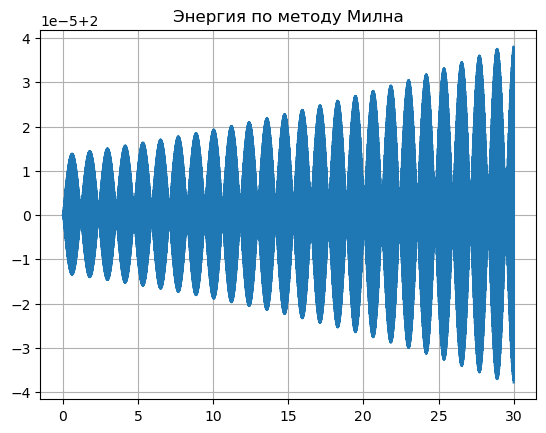

In [61]:
E = np.empty(sol.t.shape)
E = (y[1])**2/2 + (y[0]*w)**2/2
plt.plot(sol.t, E)

plt.grid(True)
plt.title(r'Энергия по методу Милна')
plt.show()